In [9]:
import numpy as np
from utils.simulacoes import simular_genetico, simular_PID
from utils.geneticos_auxiliares import gerar_populacao_inicial, grafico_convergencia

In [14]:
SEED = 23

np.random.seed(SEED)

In [5]:
tf = 100.0
dt = 0.1

X0 = 0.3066
S0 = 0.2333

states = np.array([0.3066, 0.2333])

Xsp = 0.3066

D0 = 0.35


## Mudança no setpoint ($X_{sp} = 0.34$)

In [15]:
tamanho_povo = 100
N = 20
erro_individuo_lim = 1e-2
erro_desejado = 1e-4
Xsp_novo = 0.34

gen = gerar_populacao_inicial(tamanho_povo)

Kp_AG, Ti_AG, historico_erro = simular_genetico(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, D0=D0, states=states, gen=gen, Xsp=Xsp_novo, dt=0.1, tf = 50)

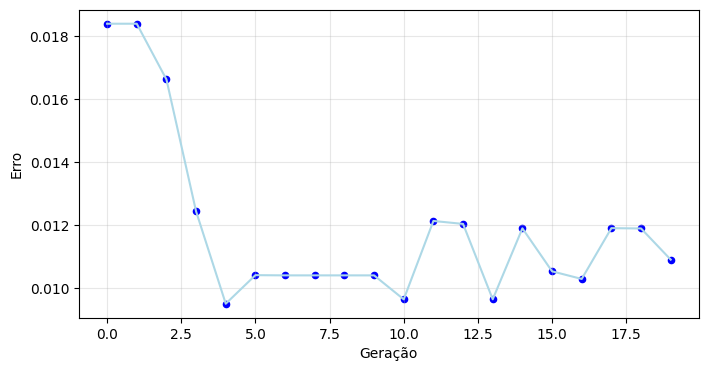

In [16]:
grafico_convergencia(historico_erro)

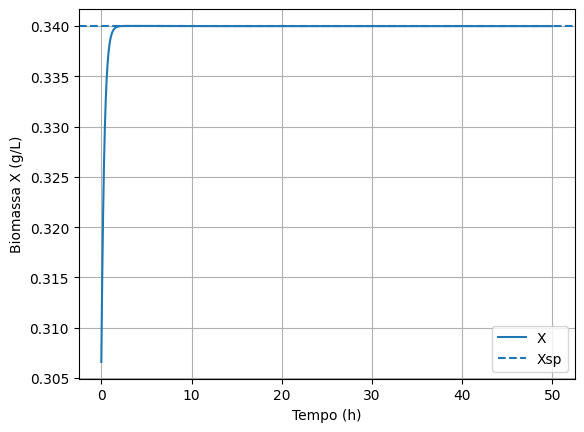

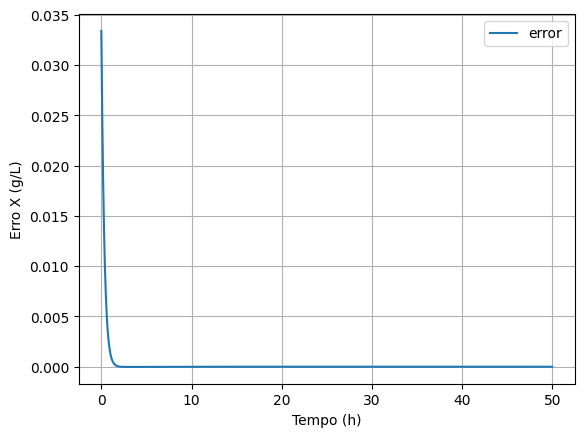

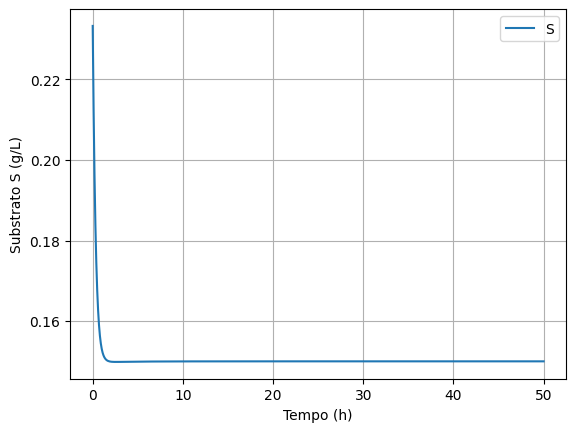

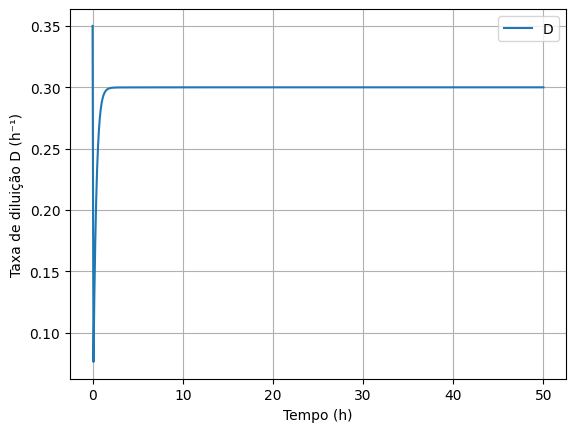

IAE: 0.010906760219430853, ISE: 0.0001915446671661797, Erro (Xsp - X): -1.2151391004522338e-11
Kp: -7.791, Ti: 1.936


In [17]:
ttop, Xtop, Stop, Dtop, IAE_top, ISE_top, erro = simular_PID(Kc=Kp_AG, Ti=Ti_AG, Xsp=Xsp_novo, states=states, tempo_final=50, dt=0.1, show=True)
print(f"IAE: {IAE_top}, ISE: {ISE_top}, Erro (Xsp - X): {erro[-1]}")
print(f"Kp: {Kp_AG}, Ti: {Ti_AG}")

## Com pertubação (+20% em SF)

In [18]:
Kp_AG_pert, Ti_AG_pert, historico_erro_pert = simular_genetico(iter_max=N, erro_desejado=erro_desejado,erro_individuo_lim=erro_individuo_lim, D0=D0, states=states, gen=gen, Xsp=Xsp, dt=0.1, tf = 50, pert=True, t_pert=20, Sf_pert = 1.2)

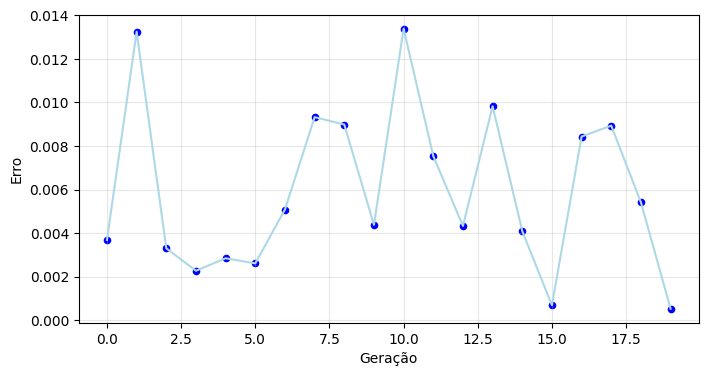

In [19]:
grafico_convergencia(historico_erro_pert)

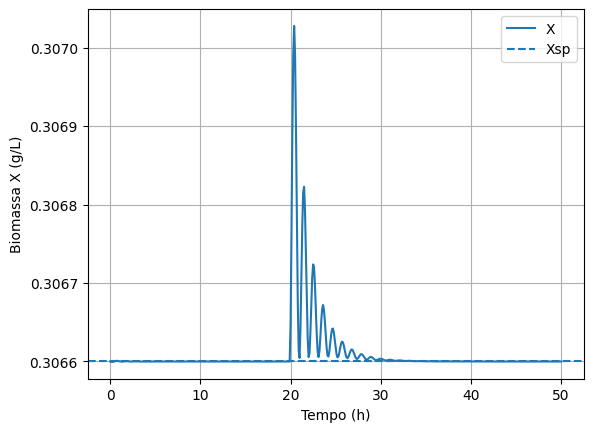

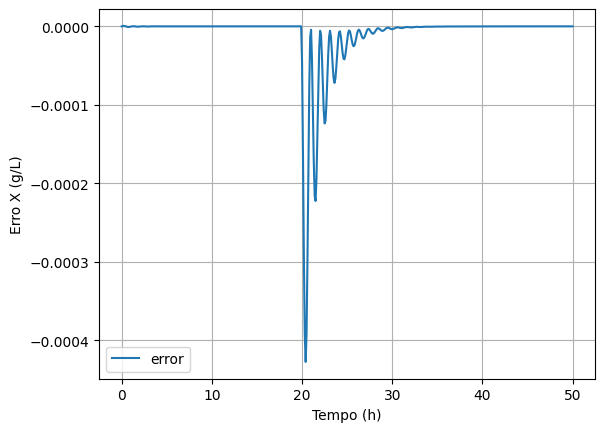

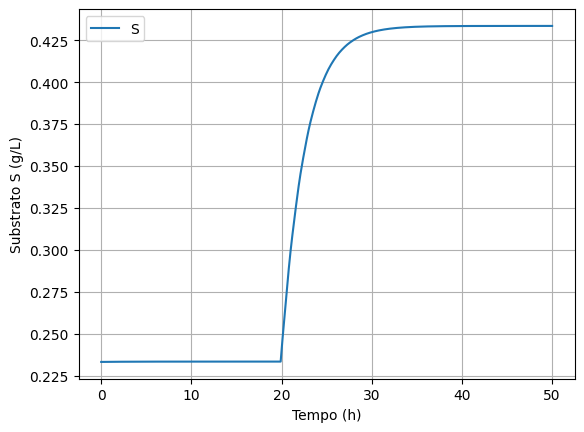

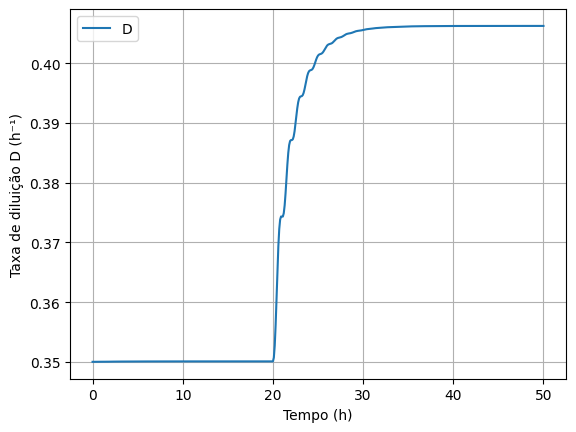

IAE: 0.000530057878689133, ISE: 1.0310834759055528e-07, Erro (Xsp - X): -7.470711826940146e-10
Kp: -2.869, Ti: 0.027


In [20]:
ttop_pert, Xtop_pert, Stop_pert, Dtop_pert, IAE_top_pert, ISE_top_pert, erro_pert = simular_PID(Kc=Kp_AG_pert, Ti=Ti_AG_pert, Xsp=Xsp, D0=D0, states=states, tempo_final=50, dt=0.1, show=True, pert=True, t_pert=20, Sf_pert = 1.2)
print(f"IAE: {IAE_top_pert}, ISE: {ISE_top_pert}, Erro (Xsp - X): {erro_pert[-1]}")
print(f"Kp: {Kp_AG_pert}, Ti: {Ti_AG_pert}")